In [2]:
import pathlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from prepare import process_regressor, model_performance_metrics,draw_scatter
from data_prune_function import get_scores,get_data,prune_rd,return_model
random_state =352
test_size = 0.1

model = {}
for modelname in ['CB','XG','GB']:
    model[modelname] = return_model(modelname,random_state=random_state)

target = 'NO(%)'
df,X,y,X_train_val,X_test,y_train_val,y_test = get_data(target = target,random_state=random_state, test_size=test_size,standardized=False)
mad = (y - y.mean()).abs().mean()
std = y.std()
print('')
print('-----------------')
print(f'{target} {y.shape[0]} {mad:.3f} {std:.3f} ')
print('-----------------')
target = 'NO(%)'
a = 'CB'
b = 'XG'
c = 'GB'


-----------------
NO(%) 242 14.156 17.853 
-----------------


In [3]:
train_pred, test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('Cat Train', y_train_val, train_pred)
model_performance_metrics('Cat Test', y_test, test_pred)

cv train R2: 0.685 (+/- 0.094) 

Cat Train mse: 0.00019 | rmse: 0.01389 | mae: 0.01068 | mape: 2.69917 | smape: 2.67146 | r2: 0.99380

Cat Test mse: 0.00383 | rmse: 0.06187 | mae: 0.04682 | mape: 14.87899 | smape: 13.21868 | r2: 0.89445



0.8944527835183073

In [4]:
folder = f'{target}/{target}_{a}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_a = f'{folder}/all_dat.pkl'

In [6]:
maes_a, rmse_a, r2_a = get_scores(model[a], X_train_val, y_train_val, X_test, y_test)
size_old_val_a, ids_a, test_scores_a, val_scores_a,test_fit_a,remove_a = prune_rd(
        model[a], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,
        threshold=maes_a / 2,train_size= 0.9, file_out=file_out_a)

Test scores: MAE=4.682, RMSE=6.187, R2=0.894
--- 0.9271376132965088 seconds ---

Iteration 0:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.6851813793182373 seconds ---
修剪模型：
Test scores: maes=4.616, rmse=5.952, r2=0.902
--- 0.726064920425415 seconds ---
Iteration 1:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 4 (ratio = 0.018)
本次循环中新训练集大小，占比: 213  (ratio = 0.982)
--- 0.6926891803741455 seconds ---
修剪模型：
Test scores: maes=4.761, rmse=6.143, r2=0.896
Val scores: maes=0.916, rmse=1.228, r2=0.996
--- 0.9069993495941162 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 8 (ratio = 0.037)
本次循环中新训练集大小，占比: 209  (ratio = 0.963)
--- 0.6939010620117188 seconds ---
修剪模型：
Test scores: maes=4.604, rmse=6.107, r2=0.897
Val scores: maes=1.305, rmse=1.535, r2=0.989
--- 0.8714504241943359 seconds ---
Iteration 3:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 12 (ratio = 0.055)
本次循环中新训练集大小，占比: 205  (ratio = 0.945)
--- 0.770007848739624 seconds ---
修剪模型：
Test scores: maes=4.724

In [10]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
def draw_scatter(train_true, train_pred, test_true, test_pred, title,
                  actual_text='actual', pred_text='prediction',save=False):

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'
    # plt.rcParams['font.sans-serif'] = ['Arial']  # 备用字体

    # 设置整张图背景颜色
    '''
    1、创建Figure时直接设置
    plt.figure(facecolor='w'))
    
    2、对现有的Figure设置
    plt.gcf()  #获取当前的图
    fig.set_facecolor('white')
    '''
    #设置的是整个图的颜色
    #plt.figure(facecolor='lightgrey')  #还可以使用RGB元组(0.8,0.8,0.8)取值范围0~1

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',  # 深灰色
        'weight': 'bold',
        'size': 18
    }

    # 绘制散点图
    sns.regplot(x=test_true, y=test_pred, color="orange", label="test")
    sns.regplot(x=train_true, y=train_pred, color="dodgerblue", label="train")

    # 设置坐标轴标签和范围
    plt.xlabel(actual_text, fontdict=font_common,weight='bold')
    plt.ylabel(pred_text, fontdict=font_common,weight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    # 设置图例
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}
    plt.legend(loc="upper right", markerscale=1.5, prop=legend_font,frameon=True, bbox_to_anchor=(0.3, 1))
    '''
    frameon:设置图例是否具有边框，bbox_to_anchor调整图例位置
    loc:控制图例在绘图区内的基准位置，可以配合bbox_to_anchor使用
    loc:    best   0自动化选择最好位置
            upper right 右上角1
            upper left  左上角2
            lower left  左下3
            lower right 右下4
            right  垂直居中 右侧5            center left 左侧垂直居中6
    '''


    #获取图中绘制的图
    ax = plt.gca()

    # 设置主刻度线 - 更明显的显示
    ax.tick_params(
        axis='both',          # 同时设置x轴和y轴
        which='major',        # 主刻度线
        direction='out',       # 刻度线方向：向内
        length=8,            # 增加刻度线长度
        width=2,             # 增加刻度线宽度
        color='black',       # 刻度线颜色
        labelsize=14,        # 标签大小
        bottom=True,         # 显示底部刻度线
        left=True,           # 显示左侧刻度线
        top=False,            # 显示顶部刻度线
        right=False           # 显示右侧刻度线
    )
    #设置颜色
    ax.set_facecolor('white')

    #设置边框
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    #设置图内网格
    plt.grid(True,
             axis='both',
             linestyle='--',
             linewidth=0.5,
             color='gray',
             alpha=0.6)

    # 添加统计信息文本
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true.values.ravel() / 100, train_pred / 100)
    _, test_rmse, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true.values.ravel() / 100, test_pred / 100)

    plt.text(60, 26, f"Train R² = {(int(train_r2*1000)/1000):.3f}", **font_common)
    plt.text(60, 18, f"Test R² = {test_r2:.3f}", **font_common)
    plt.text(60, 10, f"RMSE = {test_rmse:.3f}", **font_common)

    # 添加标题
    plt.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存图像
    if save:
        out_put = 'scatter_images1'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")


In [17]:
df_a_70 = df.loc[remove_a[20]]
x_train = df_a_70.drop(columns = ['NO(%)'])
y_train =df_a_70['NO(%)']
test =  df.drop(df_a_70.index)
x_test = test.drop(columns = ['NO(%)'])
y_test = test['NO(%)']

In [22]:
x_train

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%)
0,0,1,0,10.000000,4.000000,500,5.000000,0,0,0,0.000,0.080000,50.000000,21.000000,200.000000,1,0,0,300,13.200000,2.690000,51.800000
1,0,1,0,10.000000,4.000000,500,5.000000,0,0,1,0.300,0.080000,50.000000,21.000000,200.000000,1,0,0,300,21.962409,2.680000,74.500000
2,0,1,0,10.000000,4.000000,500,5.000000,0,0,1,0.600,0.080000,50.000000,21.000000,200.000000,1,0,0,300,27.898553,2.660000,79.300000
3,0,1,0,10.000000,4.000000,500,5.000000,0,0,1,1.800,0.080000,50.000000,21.000000,200.000000,1,0,0,300,20.871085,2.660000,71.900000
4,0,1,0,10.000000,4.000000,500,5.000000,0,0,1,6.000,0.080000,50.000000,21.000000,200.000000,1,0,0,300,19.202733,2.630000,67.300000
5,0,1,0,10.000000,4.000000,500,5.000000,0,0,0,0.000,0.080000,50.000000,12.000000,200.000000,0,0,1,30,13.200000,2.690000,61.500000
6,0,1,0,10.000000,4.000000,500,5.000000,0,0,1,0.300,0.080000,50.000000,12.000000,200.000000,0,0,1,30,15.944049,2.680000,76.400000
7,0,1,0,10.000000,4.000000,500,5.000000,0,0,1,0.600,0.080000,50.000000,12.000000,200.000000,0,0,1,30,16.421536,2.660000,78.200000
9,0,1,0,10.000000,4.000000,500,5.000000,0,0,1,6.000,0.080000,50.000000,12.000000,200.000000,0,0,1,30,16.558609,2.630000,73.700000
10,1,0,0,20.000000,2.000000,600,5.000000,0,0,0,0.000,0.020000,26.420000,2.200000,1700.000000,1,0,0,300,51.513571,2.700000,38.650000


cv train R2: 0.048 (+/- 0.136) 

Cat Train mse: 0.00010 | rmse: 0.01016 | mae: 0.00796 | mape: 1.95334 | smape: 1.94123 | r2: 0.99698

Cat Test mse: 0.00172 | rmse: 0.04144 | mae: 0.03057 | mape: 8.59042 | smape: 8.06469 | r2: 0.93692

测试图已保存：scatter_images\Rich Subset.jpg


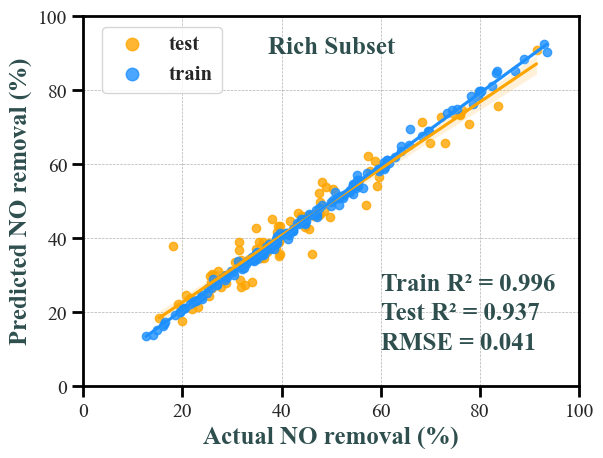

In [36]:
train_pred, test_pred = process_regressor(model[a],x_train,x_test,y_train,y_test)
model_performance_metrics('Cat Train', y_train, train_pred)
model_performance_metrics('Cat Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "Rich Subset", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 假设 df 已经包含特征和目标列
feature_columns = ['Urea','Melamine','Dcda',
                     'Time(h)','PM(g)','Heat(℃)',
                     'HR(℃/min)','ratio(%)',
                    'load(g)','NO(ppm)','rate(mL/min)'
                     ,'Xe','Wu','LED','area(cm2)',
                    'Intensity(W)','BET(m2/g)','Eg(eV)','NO2(%)','NO(%)']
X = df[feature_columns].values

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 子集大小
N = 151

# KMeans聚类
kmeans = KMeans(n_clusters=N, random_state=42)
kmeans.fit(X_scaled)

# 找每个簇中距离簇中心最近的样本
selected_idx = []

for center in kmeans.cluster_centers_:
    distances = np.linalg.norm(X_scaled - center, axis=1)
    nearest_idx = np.argmin(distances)
    selected_idx.append(nearest_idx)

# 去重（KMeans有可能簇中心很接近）
selected_idx = list(set(selected_idx))

# 如果去重后数量不足N，可以从剩余样本随机补齐
if len(selected_idx) < N:
    remaining_idx = list(set(range(len(df))) - set(selected_idx))
    n_add = N - len(selected_idx)
    selected_idx += list(np.random.choice(remaining_idx, n_add, replace=False))

# 得到多样性子集
diverse_df = df.iloc[selected_idx].copy()

C:\Users\29304\.conda\envs\work\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
x_train_1 = diverse_df.drop(columns = ['NO(%)'])
y_train_1 = diverse_df['NO(%)']
test_1 = df.drop(diverse_df.index)
x_test_1 = test_1.drop(columns = ['NO(%)'])
y_test_1 = test_1['NO(%)']

In [ ]:

x_train_1 = diverse_df.drop(columns = ['NO(%)'])
y_train_1 = diverse_df['NO(%)']
test_1 = df.drop(diverse_df.index)
x_test_1 = test_1.drop(columns = ['NO(%)'])
y_test_1 = test_1['NO(%)']
train_pred_1, test_pred_1 = process_regressor(model[a],x_train_1,x_test_1,y_train_1,y_test_1)
model_performance_metrics('Cat Test', y_test_1, test_pred_1)

cv train R2: 0.082 (+/- 0.162) 

Cat Train mse: 0.00002 | rmse: 0.00462 | mae: 0.00372 | mape: 1.03363 | smape: 1.02802 | r2: 0.99926

Cat Test mse: 0.00453 | rmse: 0.06730 | mae: 0.05225 | mape: 12.35257 | smape: 11.73908 | r2: 0.86722

测试图已保存：scatter_images\Diverse Subset.jpg


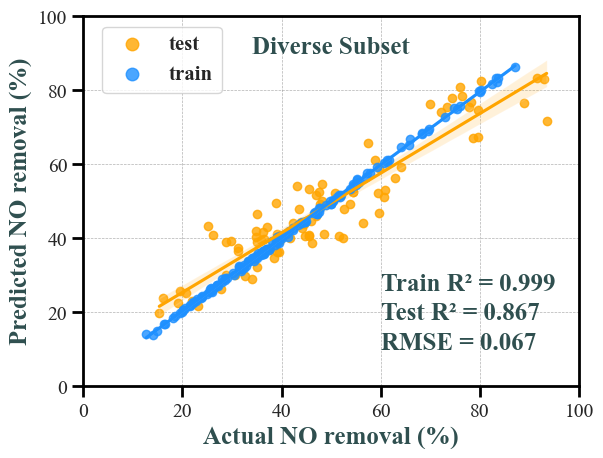

In [34]:
train_pred_1, test_pred_1 = process_regressor(model[a],x_train_1,x_test_1,y_train_1,y_test_1)
model_performance_metrics('Cat Train', y_train_1, train_pred_1)
model_performance_metrics('Cat Test', y_test_1, test_pred_1)
draw_scatter(y_train_1, train_pred_1, y_test_1, test_pred_1, "Diverse Subset", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

In [31]:
N = 151

# 单次随机抽样
random_subset = df.sample(n=N, random_state=42)  # random_state保证可复现
x_train_2 = random_subset .drop(columns = ['NO(%)'])
y_train_2 = random_subset ['NO(%)']
test_2 = df.drop(random_subset .index)
x_test_2 = test_2.drop(columns = ['NO(%)'])
y_test_2 = test_2['NO(%)']

cv train R2: 0.515 (+/- 0.041) 

Cat Train mse: 0.00008 | rmse: 0.00876 | mae: 0.00678 | mape: 1.71987 | smape: 1.70782 | r2: 0.99758

Cat Test mse: 0.00630 | rmse: 0.07937 | mae: 0.06301 | mape: 17.70369 | smape: 16.10786 | r2: 0.80090

测试图已保存：scatter_images\Random Subset.jpg


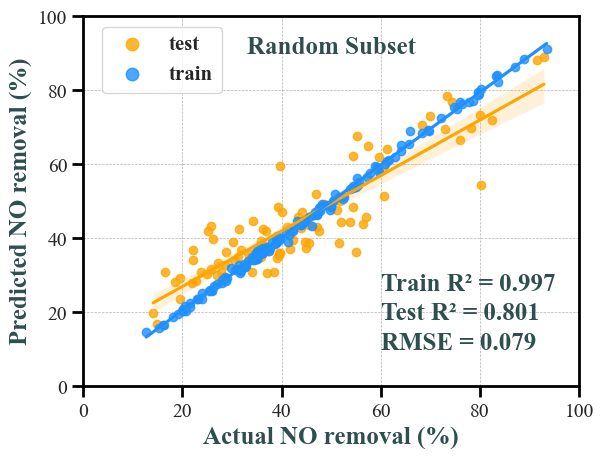

In [33]:
train_pred_2, test_pred_2 = process_regressor(model[a],x_train_2,x_test_2,y_train_2,y_test_2)
model_performance_metrics('Cat Train', y_train_2, train_pred_2)
model_performance_metrics('Cat Test', y_test_2, test_pred_2)
draw_scatter(y_train_2, train_pred_2, y_test_2, test_pred_2, "Random Subset", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

In [39]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def get_diverse_subset_fps(
        df,
        feature_columns,
        N=151,
        seed=42):

    X = df[feature_columns].values

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    np.random.seed(seed)

    n_samples = X_scaled.shape[0]

    selected = []

    # 随机选第一个点
    first_idx = np.random.randint(n_samples)

    selected.append(first_idx)

    while len(selected) < N:

        remaining = list(
            set(range(n_samples))
            - set(selected)
        )

        dist_to_selected = []

        for idx in remaining:

            d = np.min(
                np.linalg.norm(
                    X_scaled[idx]
                    - X_scaled[selected],
                    axis=1
                )
            )

            dist_to_selected.append(d)

        next_idx = remaining[
            np.argmax(dist_to_selected)
        ]

        selected.append(next_idx)

    return df.iloc[selected].copy()

In [43]:
feature_columns = ['Urea','Melamine','Dcda',
                     'Time(h)','PM(g)','Heat(℃)',
                     'HR(℃/min)','ratio(%)',
                    'load(g)','NO(ppm)','rate(mL/min)'
                     ,'Xe','Wu','LED','area(cm2)',
                    'Intensity(W)','BET(m2/g)','Eg(eV)','NO2(%)','NO(%)']
for i in range(0,5):
    diverse_df = get_diverse_subset_fps(df,feature_columns=feature_columns,N=151,seed=i)
    x_train_1 = diverse_df.drop(columns = ['NO(%)'])
    y_train_1 = diverse_df['NO(%)']
    test_1 = df.drop(diverse_df.index)
    x_test_1 = test_1.drop(columns = ['NO(%)'])
    y_test_1 = test_1['NO(%)']
    train_pred_1, test_pred_1 = process_regressor(model[a],x_train_1,x_test_1,y_train_1,y_test_1)
    model_performance_metrics('Cat Test', y_test_1, test_pred_1)

cv train R2: 0.447 (+/- 0.096) 

Cat Test mse: 0.00535 | rmse: 0.07313 | mae: 0.05922 | mape: 13.89860 | smape: 13.01845 | r2: 0.83712

cv train R2: 0.445 (+/- 0.094) 

Cat Test mse: 0.00585 | rmse: 0.07652 | mae: 0.05991 | mape: 13.91189 | smape: 13.04015 | r2: 0.82255

cv train R2: 0.430 (+/- 0.092) 

Cat Test mse: 0.00576 | rmse: 0.07589 | mae: 0.06197 | mape: 14.23285 | smape: 13.49903 | r2: 0.82321

cv train R2: 0.441 (+/- 0.112) 

Cat Test mse: 0.00593 | rmse: 0.07699 | mae: 0.06138 | mape: 14.49476 | smape: 13.47074 | r2: 0.81953

cv train R2: 0.455 (+/- 0.097) 

Cat Test mse: 0.00504 | rmse: 0.07102 | mae: 0.05671 | mape: 13.78944 | smape: 12.83639 | r2: 0.84255

